In [24]:
import os
import pickle

import numpy as np
from matplotlib import pyplot as plt

In [25]:
stat_test_name = "MNIST_pref_STOCHASTIC"

In [26]:
stat_tests_path = "stat_tests/TEST" 
LOAD_2 = False

stat_test_path = os.path.join(stat_tests_path, stat_test_name)
if not os.path.exists(stat_test_path):
    raise FileNotFoundError(f"Stat test path {stat_test_path} does not exist.")

init_params_path = os.path.join(stat_test_path, "init_params.pkl")
test_params_path = os.path.join(stat_test_path, "test_params.pkl")

with open(init_params_path, "rb") as f:
    init_params = pickle.load(f)
with open(test_params_path, "rb") as f:
    test_params = pickle.load(f)


print("Init params:")
for k, v in init_params.items():
    print(f"{k}: {v}")

num_tests = init_params["num_tests"]
# num_tests = 10 


distribution_type = init_params["distribution_type"]

tests_results = []  # 2-dim list [idx of repeated test][idx of test]
for i in range(num_tests):
    test_path = os.path.join(stat_test_path, f"test_{i}")
    test_result_path = os.path.join(test_path, "test_results.pkl")
    
    with open(test_result_path, "rb") as f:
        test_result = pickle.load(f)
        
    tests_results.append(test_result)

Init params:
test_name: MNIST_pref_STOCHASTIC
dataset_name: mnist
num_clients: 5
num_classes: 10
distribution_type: preferential_class
model_name: simple_cnn
loss_name: cross_entropy
trainer_name: sgd
train_epochs: 5
target_client: 0
num_tests: 1
hessian_method: diag_ggn_mc
stochastic_correction: True


In [27]:
if LOAD_2:
    stat_tests_path = "stat_tests/MC2" 
    stat_test_path = os.path.join(stat_tests_path, stat_test_name)
    if not os.path.exists(stat_test_path):
        raise FileNotFoundError(f"Stat test path {stat_test_path} does not exist.")

    with open(init_params_path, "rb") as f:
        init_params = pickle.load(f)
    with open(test_params_path, "rb") as f:
        test_params = pickle.load(f)


    print("Init params:")
    for k, v in init_params.items():
        print(f"{k}: {v}")

    num_tests2 = init_params["num_tests"]
    num_tests2 = 10 

    for i in range(num_tests2):
        test_path = os.path.join(stat_test_path, f"test_{i}")
        test_result_path = os.path.join(test_path, "test_results.pkl")
        
        with open(test_result_path, "rb") as f:
            test_result = pickle.load(f)
            
        tests_results.append(test_result)

    num_tests += num_tests2

In [28]:
if distribution_type == "random" or distribution_type == "dirichlet":
    for i in range(num_tests):
        for j in range(len(tests_results[i])):
            tests_results[i][j]['trained_target_accuracy'] = tests_results[i][j]['trained_clients_accuracies'][init_params['target_client']]
            tests_results[i][j]['benchmark_target_accuracy'] = tests_results[i][j]['benchmark_clients_accuracies'][init_params['target_client']]
            tests_results[i][j]['reset_target_accuracy'] = tests_results[i][j]['reset_clients_accuracies'][init_params['target_client']]
            tests_results[i][j]['retrained_target_accuracy'] = tests_results[i][j]['retrained_clients_accuracies'][init_params['target_client']]
            tests_results[i][j]['random_reset_target_accuracy'] = tests_results[i][j]['random_reset_clients_accuracies'][init_params['target_client']]
            tests_results[i][j]['random_retrained_target_accuracy'] = tests_results[i][j]['random_retrained_clients_accuracies'][init_params['target_client']]
if distribution_type == "preferential_class":
    for i in range(num_tests):
        for j in range(len(tests_results[i])):
            tests_results[i][j]['trained_target_accuracy'] = tests_results[i][j]['trained_class_accuracies'][init_params['target_client']+init_params['num_clients']]
            tests_results[i][j]['benchmark_target_accuracy'] = tests_results[i][j]['benchmark_class_accuracies'][init_params['target_client']+init_params['num_clients']]
            tests_results[i][j]['reset_target_accuracy'] = tests_results[i][j]['reset_class_accuracies'][init_params['target_client']+init_params['num_clients']]
            tests_results[i][j]['retrained_target_accuracy'] = tests_results[i][j]['retrained_class_accuracies'][init_params['target_client']+init_params['num_clients']]
            tests_results[i][j]['random_reset_target_accuracy'] = tests_results[i][j]['random_reset_class_accuracies'][init_params['target_client']+init_params['num_clients']]
            tests_results[i][j]['random_retrained_target_accuracy'] = tests_results[i][j]['random_retrained_class_accuracies'][init_params['target_client']+init_params['num_clients']]

for i in range(num_tests):
        for j in range(len(tests_results[i])):
            tests_results[i][j]['trained_target_accuracy'] = tests_results[i][j]['trained_clients_accuracies'][init_params['target_client']]
            tests_results[i][j]['benchmark_target_accuracy'] = tests_results[i][j]['benchmark_clients_accuracies'][init_params['target_client']]
            tests_results[i][j]['reset_target_accuracy'] = tests_results[i][j]['reset_clients_accuracies'][init_params['target_client']]
            tests_results[i][j]['retrained_target_accuracy'] = tests_results[i][j]['retrained_clients_accuracies'][init_params['target_client']]
            tests_results[i][j]['random_reset_target_accuracy'] = tests_results[i][j]['random_reset_clients_accuracies'][init_params['target_client']]
            tests_results[i][j]['random_retrained_target_accuracy'] = tests_results[i][j]['random_retrained_clients_accuracies'][init_params['target_client']]

In [29]:
subtest = 0

subtest_params = []
subtest_results = []    # 2-dim list [idx of test][idx of repeated test]
for i, test_param in enumerate(test_params):
    if test_param["subtest"] == subtest:
        subtest_params.append(test_param)
        subtest_results.append([])
        for j in range(num_tests):
            subtest_results[-1].append(tests_results[j][i])

n=None
if n is not None:
    subtest_params = subtest_params[:n]
    subtest_results = subtest_results[:n]

print("Subtest params:")
for key, value_key in subtest_params[0].items():
    if key == "unlearning_percentage":
        continue
    print(f"{key}: {value_key}")

print(f"\nAvailable results:")
for key in subtest_results[0][0].keys():
    print(key)

unlearning_percentages = []
for test_param in subtest_params:
    unlearning_percentages.append(int(test_param["unlearning_percentage"]))

print(f"\nUnlearning percentages: {unlearning_percentages}")

Subtest params:
tests: ['test_accuracy', 'clients_accuracies', 'class_accuracies']
retrain_epochs: 1
subtest: 0
unlearning_method: information

Available results:
num_total_params
num_reset_params
reset_params_percentage
communication_metrics
total_communication_rounds
total_communication_bytes
benchmark_communication_rounds
benchmark_communication_bytes
initial_training_rounds
initial_training_bytes
unlearning_hessian_rounds
unlearning_hessian_bytes
unlearning_retraining_rounds
unlearning_retraining_bytes
unlearning_total_rounds
unlearning_total_bytes
trained_test_accuracy
benchmark_test_accuracy
reset_test_accuracy
retrained_test_accuracy
random_reset_test_accuracy
random_retrained_test_accuracy
trained_clients_accuracies
benchmark_clients_accuracies
reset_clients_accuracies
retrained_clients_accuracies
random_reset_clients_accuracies
random_retrained_clients_accuracies
trained_class_accuracies
benchmark_class_accuracies
reset_class_accuracies
retrained_class_accuracies
random_reset_

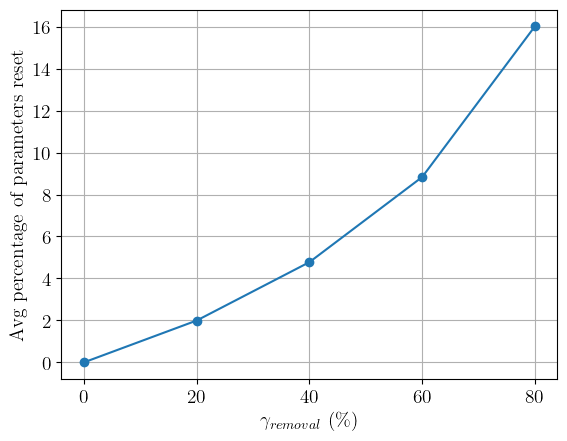

ValueError: 90 is not in list

In [30]:
# Compute avg number of reset parameters percentage
plt.rc('text', usetex=True)
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : 14}

plt.rc('font', **font)
avg_reset_parameters = [np.mean([test_result['reset_params_percentage'] for test_result in subtest_result]) for subtest_result in subtest_results]
plt.plot(unlearning_percentages, avg_reset_parameters, marker='o')
plt.ylabel("Avg percentage of parameters reset")

plt.xlabel(r"$\gamma_{removal}$ $(\%)$")
plt.grid()
plt.savefig("plots/parameters_reset.png", dpi=300)
plt.show()
plt.rc('text', usetex=False)
plt.style.use(['default'])

perc = 90
idx = unlearning_percentages.index(perc)
print(f"At {perc}% unlearning, avg reset parameters: {avg_reset_parameters[idx]:.2f}%")

In [31]:
def compute_metrics(res, model_key):
    mia_type_key = 'mia_nn'
    mia_result_key = 'accuracy'

    model_test_acc = res[model_key + '_test_accuracy']
    model_target_acc = res[model_key + '_target_accuracy']

    benchmark_test_acc = res['benchmark_test_accuracy']
    benchmark_target_acc = res['benchmark_target_accuracy']

    trained_test_acc = res['trained_test_accuracy']
    trained_target_acc = res['trained_target_accuracy']

    nta = model_test_acc / benchmark_test_acc
    nfs = (model_target_acc - trained_target_acc) / (benchmark_target_acc - trained_target_acc) if benchmark_target_acc != trained_target_acc else 0

    try:
        model_mia_acc = res[model_key + '_' + mia_type_key][mia_result_key]
        benchmark_mia_acc = res['benchmark_' + mia_type_key][mia_result_key]
        trained_mia_acc = res['trained_' + mia_type_key][mia_result_key]
        nfs_mia = (model_mia_acc - trained_mia_acc) / (benchmark_mia_acc - trained_mia_acc) if benchmark_mia_acc != trained_mia_acc else 0
    except KeyError:
        nfs_mia = None

    return nta, nfs, nfs_mia

for subtest_result in subtest_results:
    for test_result in subtest_result:
        nta, nfs, nfs_mia = compute_metrics(test_result, 'reset')
        test_result['reset_nta'] = nta
        test_result['reset_nfs'] = nfs
        test_result['reset_nfs_mia'] = nfs_mia

        nta, nfs, nfs_mia = compute_metrics(test_result, 'retrained')
        test_result['retrained_nta'] = nta
        test_result['retrained_nfs'] = nfs
        test_result['retrained_nfs_mia'] = nfs_mia

        nta, nfs, nfs_mia = compute_metrics(test_result, 'random_reset')
        test_result['random_reset_nta'] = nta
        test_result['random_reset_nfs'] = nfs
        test_result['random_reset_nfs_mia'] = nfs_mia

        nta, nfs, nfs_mia = compute_metrics(test_result, 'random_retrained')
        test_result['random_retrained_nta'] = nta
        test_result['random_retrained_nfs'] = nfs
        test_result['random_retrained_nfs_mia'] = nfs_mia

In [32]:
def compute_avg_std(subtest_results, key):
    avg = []
    std = []
    for subtest_result in subtest_results:
        values = [test_result[key] for test_result in subtest_result]
        avg.append(np.mean(values))
        std.append(np.std(values))
    return avg, std

# Compute NFS (Normalized Forgetting Score)
reset_nfs_avg, reset_nfs_std = compute_avg_std(subtest_results, 'reset_nfs')
retrained_nfs_avg, retrained_nfs_std = compute_avg_std(subtest_results, 'retrained_nfs')
random_reset_nfs_avg, random_reset_nfs_std = compute_avg_std(subtest_results, 'random_reset_nfs')
random_retrained_nfs_avg, random_retrained_nfs_std = compute_avg_std(subtest_results, 'random_retrained_nfs')

# Compute NFS_MIA (Normalized Forgetting Score based on MIA)
try:
    reset_nfs_mia_avg, reset_nfs_mia_std = compute_avg_std(subtest_results, 'reset_nfs_mia')
    retrained_nfs_mia_avg, retrained_nfs_mia_std = compute_avg_std(subtest_results, 'retrained_nfs_mia')
    random_reset_nfs_mia_avg, random_reset_nfs_mia_std = compute_avg_std(subtest_results, 'random_reset_nfs_mia')
    random_retrained_nfs_mia_avg, random_retrained_nfs_mia_std = compute_avg_std(subtest_results, 'random_retrained_nfs_mia')
except:
    reset_nfs_mia_avg, reset_nfs_mia_std = None, None
    retrained_nfs_mia_avg, retrained_nfs_mia_std = None, None
    random_reset_nfs_mia_avg, random_reset_nfs_mia_std = None, None
    random_retrained_nfs_mia_avg, random_retrained_nfs_mia_std = None, None

# Compute NTA (Normalized Test Accuracy)
reset_nta_avg, reset_nta_std = compute_avg_std(subtest_results, 'reset_nta')
retrained_nta_avg, retrained_nta_std = compute_avg_std(subtest_results, 'retrained_nta')
random_reset_nta_avg, random_reset_nta_std = compute_avg_std(subtest_results, 'random_reset_nta')
random_retrained_nta_avg, random_retrained_nta_std = compute_avg_std(subtest_results, 'random_retrained_nta')

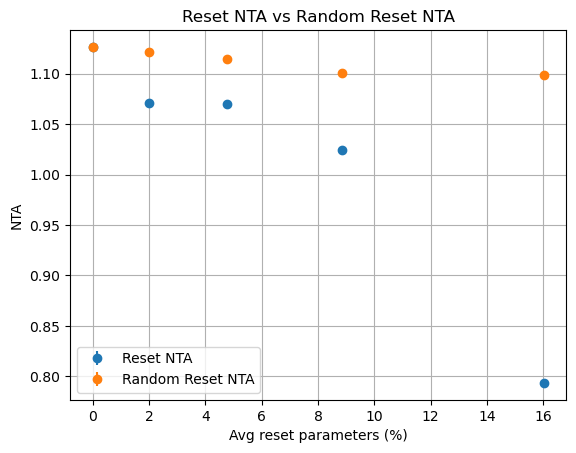

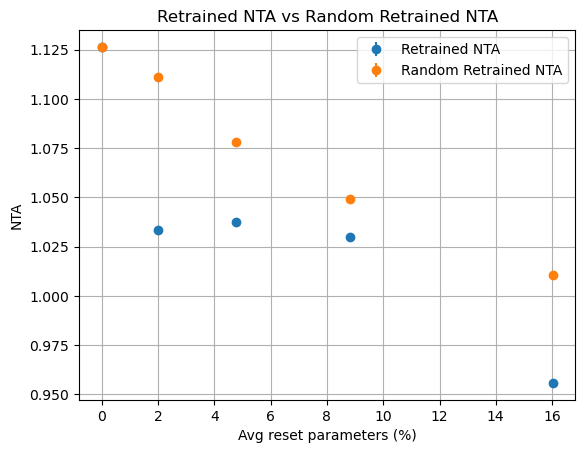

In [33]:
plt.errorbar(avg_reset_parameters, reset_nta_avg, yerr=reset_nta_std, label='Reset NTA', marker='o', linestyle='None')
plt.errorbar(avg_reset_parameters, random_reset_nta_avg, yerr=random_reset_nta_std, label='Random Reset NTA', marker='o', linestyle='None')
plt.title("Reset NTA vs Random Reset NTA")
plt.xlabel("Avg reset parameters (%)")
plt.ylabel("NTA")
plt.legend()
plt.grid()
plt.show()

plt.errorbar(avg_reset_parameters, retrained_nta_avg, yerr=retrained_nta_std, label='Retrained NTA', marker='o', linestyle='None')
plt.errorbar(avg_reset_parameters, random_retrained_nta_avg, yerr=random_retrained_nta_std, label='Random Retrained NTA', marker='o', linestyle='None')
plt.title("Retrained NTA vs Random Retrained NTA")
plt.xlabel("Avg reset parameters (%)")
plt.ylabel("NTA")
plt.legend()
plt.grid()
plt.show()


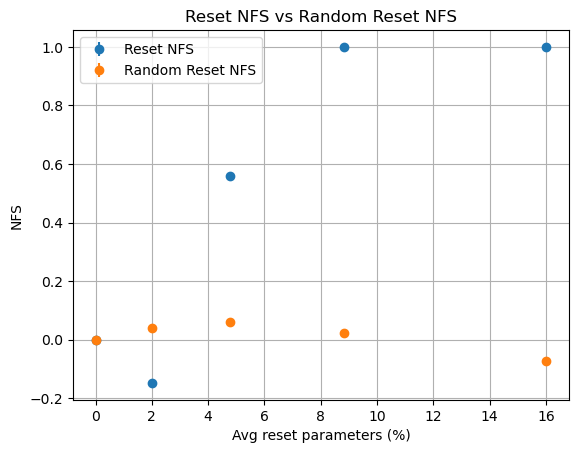

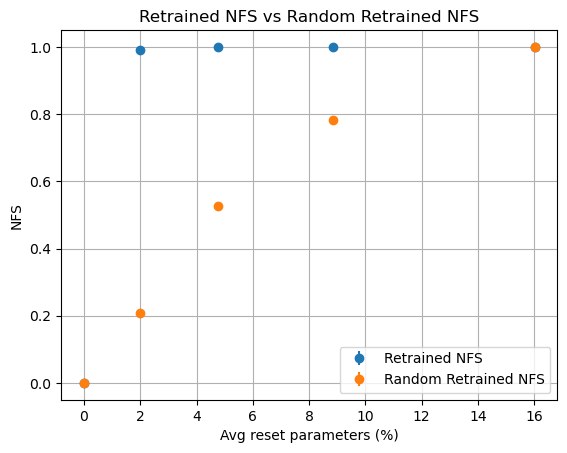

In [34]:
plt.errorbar(avg_reset_parameters, reset_nfs_avg, yerr=reset_nfs_std, label='Reset NFS', marker='o', linestyle='None')
plt.errorbar(avg_reset_parameters, random_reset_nfs_avg, yerr=random_reset_nfs_std, label='Random Reset NFS', marker='o', linestyle='None')
plt.title("Reset NFS vs Random Reset NFS")
plt.xlabel("Avg reset parameters (%)")
plt.ylabel("NFS")
plt.legend()
plt.grid()
plt.show()


plt.errorbar(avg_reset_parameters, retrained_nfs_avg, yerr=retrained_nfs_std, label='Retrained NFS', marker='o', linestyle='None')
plt.errorbar(avg_reset_parameters, random_retrained_nfs_avg, yerr=random_retrained_nfs_std, label='Random Retrained NFS', marker='o', linestyle='None')
plt.title("Retrained NFS vs Random Retrained NFS")
plt.xlabel("Avg reset parameters (%)")
plt.ylabel("NFS")
plt.legend()
plt.grid()
plt.show()


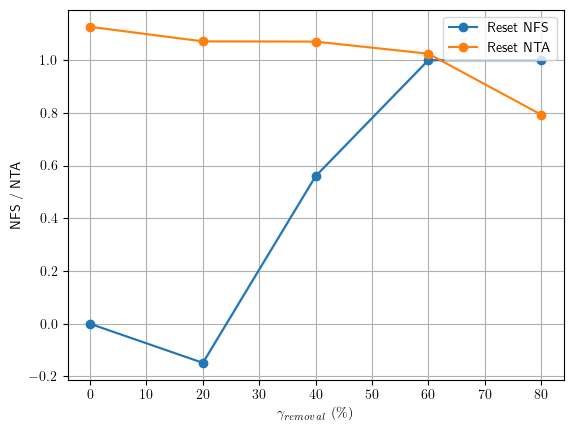

In [35]:
# plt.errorbar(unlearning_percentages, reset_nfs_avg, yerr=reset_nfs_std, label='Reset NFS', marker='o', linestyle='None')
# plt.errorbar(unlearning_percentages, reset_nta_avg, yerr=reset_nta_std, label='Reset NTA', marker='o', linestyle='None')
plt.rc('text', usetex=True)
plt.rc('text', usetex=True)
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : 14}

plt.plot(unlearning_percentages, reset_nfs_avg, label='Reset NFS', marker='o', linestyle='-')
plt.plot(unlearning_percentages, reset_nta_avg, label='Reset NTA', marker='o', linestyle='-')

plt.fill_between(np.array(unlearning_percentages), np.array(reset_nfs_avg)-np.array(reset_nfs_std), np.array(reset_nfs_avg)+np.array(reset_nfs_std), alpha=0.2, color='blue')
plt.fill_between(np.array(unlearning_percentages), np.array(reset_nta_avg)-np.array(reset_nta_std), np.array(reset_nta_avg)+np.array(reset_nta_std), alpha=0.2, color='orange')

plt.xlabel(r"$\gamma_{removal}$ $(\%)$")
plt.ylabel("NFS / NTA")
plt.legend()
plt.grid()
plt.savefig("plots/reset_NFS_NTA.png", dpi=300)
plt.show()
plt.rc('text', usetex=False)
plt.style.use(['default'])


In [36]:
# Compute NFS_MIA
if distribution_type == "random" or distribution_type == "dirichlet":
    plt.errorbar(avg_reset_parameters, reset_nfs_mia_avg, yerr=reset_nfs_mia_std, label='Reset NFS_MIA', marker='o', linestyle='None')
    plt.errorbar(avg_reset_parameters, random_reset_nfs_mia_avg, yerr=random_reset_nfs_mia_std, label='Random Reset NFS_MIA', marker='o', linestyle='None')
    plt.title("Reset NFS_MIA vs Random Reset NFS_MIA")
    plt.xlabel("Avg reset parameters (%)")
    plt.ylabel("NFS_MIA")
    plt.legend()
    plt.grid()
    plt.show()

    plt.errorbar(avg_reset_parameters, retrained_nfs_mia_avg, yerr=retrained_nfs_mia_std, label='Retrained NFS_MIA', marker='o', linestyle='None')
    plt.errorbar(avg_reset_parameters, random_retrained_nfs_mia_avg, yerr=random_retrained_nfs_mia_std, label='Random Retrained NFS_MIA', marker='o', linestyle='None')
    plt.title("Retrained NFS_MIA vs Random Retrained NFS_MIA")
    plt.xlabel("Avg reset parameters (%)")
    plt.ylabel("NFS_MIA")
    plt.legend()
    plt.grid()
    plt.show()

In [37]:
# Find best reset for each test
best_reset_idxs = []
for i in range(num_tests):
    reset_nta = [subtest_results[j][i]['reset_nta'] for j in range(len(subtest_results))]
    if distribution_type == "random":
        reset_nfs_mia = [subtest_results[j][i]['reset_nfs_mia'] for j in range(len(subtest_results))]
        best_reset_idx = np.argmin([np.sqrt((1 - nfs_mia)**2 + (1 - nta)**2) for nfs_mia, nta in zip(reset_nfs_mia, reset_nta)])
        best_reset_idxs.append(best_reset_idx)
    else:
        reset_nfs = [subtest_results[j][i]['reset_nfs'] for j in range(len(subtest_results))]
        best_reset_idx = np.argmin([np.sqrt((1 - nfs)**2 + (1 - nta)**2) for nfs, nta in zip(reset_nfs, reset_nta)])
        best_reset_idxs.append(best_reset_idx)

In [38]:
plots_folder = "plots"
if not os.path.exists(plots_folder):
    os.makedirs(plots_folder)

dataset_name = init_params['dataset_name']
distribution_type = init_params['distribution_type']

save_path_pref = os.path.join(plots_folder, f"{dataset_name}_{distribution_type}")

In [39]:
if distribution_type == "random":
    plt.plot(reset_nfs_mia_avg, reset_nta_avg, label='Reset', marker='')
    plt.plot(random_reset_nfs_mia_avg, random_reset_nta_avg, label='Random Reset', marker='')

    xlim = plt.xlim()
    ylim = plt.ylim()
    plt.scatter([1], [1], label='Retrain from scratch', color='red', marker='x', s=100)
    plt.hlines(1, xlim[0], xlim[1], colors='red', linestyles=(0, (5, 10)))
    plt.vlines(1, ylim[0], ylim[1], colors='red', linestyles=(0, (5, 10)))
    plt.xlim(xlim)
    plt.ylim(ylim)

    plt.xlim(right=1.1)
    plt.ylim(top=1.1)

    plt.xlabel('NFS MIA')
    plt.ylabel("NTA")
    plt.legend()
    plt.grid()
    plt.savefig(save_path_pref + "_NFS_MIA_vs_NTA_reset.png")
    plt.show()

    #scatter plot all points
    reset_nfs_mia = []
    reset_nta = []
    random_reset_nfs_mia = []
    random_reset_nta = []
    for test_result in subtest_results:
        for result in test_result:
            reset_nfs_mia.append(result['reset_nfs_mia'])
            reset_nta.append(result['reset_nta'])
            random_reset_nfs_mia.append(result['random_reset_nfs_mia'])
            random_reset_nta.append(result['random_reset_nta'])

    plt.scatter(reset_nfs_mia, reset_nta, label='Reset', alpha=0.5)
    xlim = plt.xlim()
    ylim = plt.ylim()
    plt.scatter([1], [1], label='Retrain from scratch', color='red', marker='x', s=100)
    plt.hlines(1, xlim[0], xlim[1], colors='red', linestyles=(0, (5, 10)))
    plt.vlines(1, ylim[0], ylim[1], colors='red', linestyles=(0, (5, 10)))
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.scatter(random_reset_nfs_mia, random_reset_nta, label='Random Reset', alpha=0.5)
    plt.xlabel('NFS MIA')
    plt.ylabel("NTA")
    plt.legend()
    plt.grid()

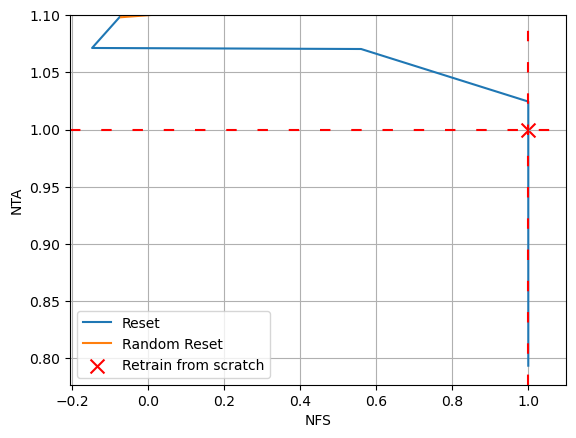

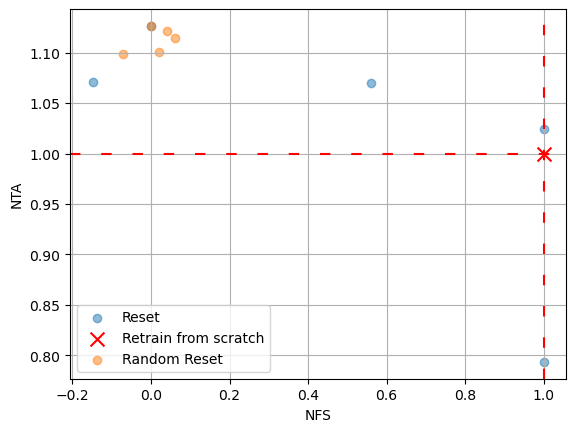

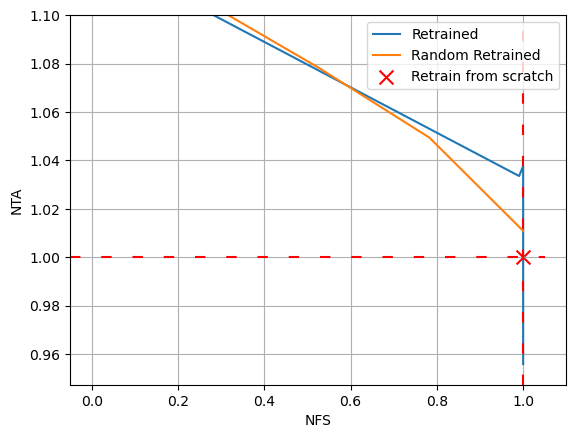

In [40]:
if distribution_type == "preferential_class" or distribution_type == "dirichlet":
    plt.plot(reset_nfs_avg, reset_nta_avg, label='Reset', marker='')
    plt.plot(random_reset_nfs_avg, random_reset_nta_avg, label='Random Reset', marker='')

    xlim = plt.xlim()
    ylim = plt.ylim()
    plt.scatter([1], [1], label='Retrain from scratch', color='red', marker='x', s=100)
    plt.hlines(1, xlim[0], xlim[1], colors='red', linestyles=(0, (5, 10)))
    plt.vlines(1, ylim[0], ylim[1], colors='red', linestyles=(0, (5, 10)))
    plt.xlim(xlim)
    plt.ylim(ylim)

    plt.xlim(right=1.1)
    plt.ylim(top=1.1)

    plt.xlabel("NFS")
    plt.ylabel("NTA")
    plt.legend()
    plt.grid()
    plt.savefig(save_path_pref + "_NFS_vs_NTA_reset.png")
    plt.show()

    #scatter plot all points
    reset_nfs = []
    reset_nta = []
    random_reset_nfs = []
    random_reset_nta = []
    for test_result in subtest_results:
        for result in test_result:
            reset_nfs.append(result['reset_nfs'])
            reset_nta.append(result['reset_nta'])
            random_reset_nfs.append(result['random_reset_nfs'])
            random_reset_nta.append(result['random_reset_nta'])

    plt.scatter(reset_nfs, reset_nta, label='Reset', alpha=0.5)
    xlim = plt.xlim()
    ylim = plt.ylim()
    plt.scatter([1], [1], label='Retrain from scratch', color='red', marker='x', s=100)
    plt.hlines(1, xlim[0], xlim[1], colors='red', linestyles=(0, (5, 10)))
    plt.vlines(1, ylim[0], ylim[1], colors='red', linestyles=(0, (5, 10)))
    plt.xlim(xlim)
    plt.ylim(ylim)
    plt.scatter(random_reset_nfs, random_reset_nta, label='Random Reset', alpha=0.5)
    plt.xlabel('NFS')
    plt.ylabel("NTA")
    plt.legend()
    plt.grid()
    plt.show()

    
    plt.plot(retrained_nfs_avg, retrained_nta_avg, label='Retrained', marker='')
    plt.plot(random_retrained_nfs_avg, random_retrained_nta_avg, label='Random Retrained', marker='')

    xlim = plt.xlim()
    ylim = plt.ylim()
    plt.scatter([1], [1], label='Retrain from scratch', color='red', marker='x', s=100)
    plt.hlines(1, xlim[0], xlim[1], colors='red', linestyles=(0, (5, 10)))
    plt.vlines(1, ylim[0], ylim[1], colors='red', linestyles=(0, (5, 10)))
    plt.xlim(xlim)
    plt.ylim(ylim)

    plt.xlim(right=1.1)
    plt.ylim(top=1.1)

    plt.xlabel("NFS")
    plt.ylabel("NTA")
    plt.legend()
    plt.grid()
    plt.savefig(save_path_pref + "_NFS_vs_NTA_retrained.png")
    plt.show()

In [41]:
latex_dist : dict = {
    "random": "Random",
    "dirichlet": "Dirichlet",
    "preferential_class": "Preferential"
}

latex_datasets : dict = {
    "cifar10": "CIFAR-10",
    "FashionMNIST": "FMNIST",
    "mnist": "MNIST"
}

prefix = f"{latex_datasets[dataset_name]} & {latex_dist[distribution_type]} &"

BEST ALPHA NTA
MNIST & Preferential & $88.02 \pm 0.00$ & $78.14 \pm 0.00$ & $80.05 \pm 0.00$ & $1.02 \pm 0.00$ \\
BEST ALPHA NFS
MNIST & Preferential & $84.08 \pm 0.00$ & $0.00 \pm 0.00$ & $0.00 \pm 0.00$ & $1.00 \pm 0.00$ \\
BEST RESET
MNIST & Preferential & $60.00 \pm 0.00$ & $8.83 \pm 0.00$ \\


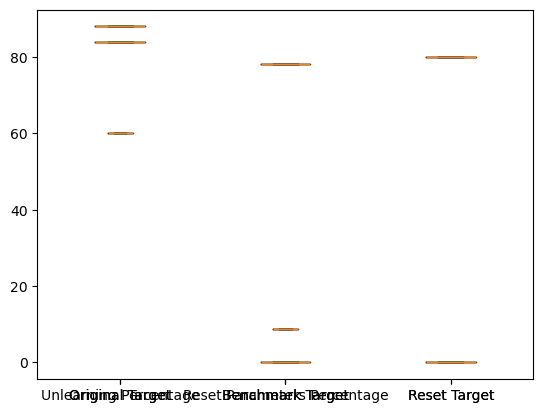

In [42]:
nta_s = [subtest_results[best_reset_idxs[i]][i]['reset_nta'] for i in range(num_tests)]
original_test_accuracies = [subtest_results[best_reset_idxs[i]][i]['trained_test_accuracy']*100 for i in range(num_tests)] # [idx of repeated test]
benchmark_test_accuracies = [subtest_results[best_reset_idxs[i]][i]['benchmark_test_accuracy']*100 for i in range(num_tests)] # [idx of repeated test]
reset_test_accuracies = [subtest_results[best_reset_idxs[i]][i]['reset_test_accuracy']*100 for i in range(num_tests)] # [idx of repeated test]

plt.boxplot([original_test_accuracies, benchmark_test_accuracies, reset_test_accuracies], tick_labels=['Original Target', 'Benchmark Target', 'Reset Target'])
#plt.show()

print("BEST ALPHA NTA")
print(f"{prefix} ${np.mean(original_test_accuracies):.2f} \\pm {np.std(original_test_accuracies):.2f}$ & ${np.mean(benchmark_test_accuracies):.2f} \\pm {np.std(benchmark_test_accuracies):.2f}$ & ${np.mean(reset_test_accuracies):.2f} \\pm {np.std(reset_test_accuracies):.2f}$ & ${np.mean(nta_s):.2f} \\pm {np.std(nta_s):.2f}$ \\\\")

nfs_s = [subtest_results[best_reset_idxs[i]][i]['reset_nfs'] for i in range(num_tests)]
original_target_accuracies = [subtest_results[best_reset_idxs[i]][i]['trained_target_accuracy']*100 for i in range(num_tests)] # [idx of repeated test]
benchmark_target_accuracies = [subtest_results[best_reset_idxs[i]][i]['benchmark_target_accuracy']*100 for i in range(num_tests)] # [idx of repeated test]
reset_target_accuracies = [subtest_results[best_reset_idxs[i]][i]['reset_target_accuracy']*100 for i in range(num_tests)] # [idx of repeated test]

plt.boxplot([original_target_accuracies, benchmark_target_accuracies, reset_target_accuracies], tick_labels=['Original Target', 'Benchmark Target', 'Reset Target'])
#plt.show()

print("BEST ALPHA NFS")
print(f"{prefix} ${np.mean(original_target_accuracies):.2f} \\pm {np.std(original_target_accuracies):.2f}$ & ${np.mean(benchmark_target_accuracies):.2f} \\pm {np.std(benchmark_target_accuracies):.2f}$ & ${np.mean(reset_target_accuracies):.2f} \\pm {np.std(reset_target_accuracies):.2f}$ & ${np.mean(nfs_s):.2f} \\pm {np.std(nfs_s):.2f}$ \\\\")

try:
    nfs_mia_s = [subtest_results[best_reset_idxs[i]][i]['reset_nfs_mia'] for i in range(num_tests)]
    original_mia_accuracies = [subtest_results[best_reset_idxs[i]][i]['trained_mia_nn']['accuracy']*100 for i in range(num_tests)] # [idx of repeated test]
    benchmark_mia_accuracies = [subtest_results[best_reset_idxs[i]][i]['benchmark_mia_nn']['accuracy']*100 for i in range(num_tests)] # [idx of repeated test]
    reset_mia_accuracies = [subtest_results[best_reset_idxs[i]][i]['reset_mia_nn']['accuracy']*100 for i in range(num_tests)] # [idx of repeated test]

    plt.boxplot([original_mia_accuracies, benchmark_mia_accuracies, reset_mia_accuracies], tick_labels=['Original Target', 'Benchmark Target', 'Reset Target'])
    #plt.show()
    
    print("BEST ALPHA NFS_MIA")
    print(f"{prefix} ${np.mean(original_mia_accuracies):.2f} \\pm {np.std(original_mia_accuracies):.2f}$ & ${np.mean(benchmark_mia_accuracies):.2f} \\pm {np.std(benchmark_mia_accuracies):.2f}$ & ${np.mean(reset_mia_accuracies):.2f} \\pm {np.std(reset_mia_accuracies):.2f}$ & ${np.mean(nfs_mia_s):.2f} \\pm {np.std(nfs_mia_s):.2f}$ \\\\")
except:
    pass

alphas = [unlearning_percentages[best_reset_idxs[i]] for i in range(num_tests)]
reset_param_percentages = [subtest_results[best_reset_idxs[i]][i]['reset_params_percentage'] for i in range(num_tests)]

plt.boxplot([alphas, reset_param_percentages], tick_labels=['Unlearning Percentage', 'Reset Parameters Percentage'])
#plt.show()

print("BEST RESET")
print(f"{prefix} ${np.mean(alphas):.2f} \\pm {np.std(alphas):.2f}$ & ${np.mean(reset_param_percentages):.2f} \\pm {np.std(reset_param_percentages):.2f}$ \\\\")


In [43]:
from datetime import datetime
start_retrain_str = "15:28:36,006"
stop_retrain_str = "15:41:34,678"
start_reset_str = "15:41:34,678"
stop_reset_str = "15:45:24,672"
start_retrain = datetime.strptime(start_retrain_str, "%H:%M:%S,%f")
stop_retrain = datetime.strptime(stop_retrain_str, "%H:%M:%S,%f")
start_reset = datetime.strptime(start_reset_str, "%H:%M:%S,%f")
stop_reset = datetime.strptime(stop_reset_str, "%H:%M:%S,%f")
retrain_time = (stop_retrain - start_retrain).total_seconds()
reset_time = (stop_reset - start_reset).total_seconds()
print(f"${int(retrain_time)}$ & ${int(reset_time)}$ & ${(reset_time/retrain_time):.2f}$\\\\")

$778$ & $229$ & $0.30$\\
